<a href="https://colab.research.google.com/github/christinengalle19-collab/Christine-Tsafong-BIA-PROJECTS/blob/main/Project_5_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##The 20 Newsgroups dataset is a classic text collection used for experimenting with machine learning techniques in natural language processing. It contains around 20,000 posts from 20 different discussion groups, covering topics like sports, politics, science, religion, and technology. Each document is raw, messy, and highly realistic, making the dataset ideal for testing text classification, clustering, topic modeling, and feature extraction methods


In [ ]:
#import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import fetch_20newsgroups

In [ ]:
categories = [
    'talk.religion.misc',
    'comp.graphics',
    'sci.space',
]

print("Loading 20 newsgroups dataset for categories:")
print(categories)

Loading 20 newsgroups dataset for categories:
['talk.religion.misc', 'comp.graphics', 'sci.space']


In [ ]:
#Load the Newsgroups dataset using scikit-learn.
dataset = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))


In [ ]:
import string
#Tokenization
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
raw_text = dataset.data

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
#Raws text, document and labels
raw_text = dataset.data
documents = dataset.filenames
labels = dataset.target


In [ ]:
from collections import Counter
print(np.unique(labels))


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


Perform basic text preprocessing including tokenization, removing stopwords, and punctuation.


In [ ]:
nltk.download('punkt_tab')
lemmatizer = WordNetLemmatizer()
for i in range(len(dataset.data)):
    word_list = word_tokenize(dataset.data[i])
    lemmatized_doc = ""
    for word in word_list:
        lemmatized_doc = lemmatized_doc + " " + lemmatizer.lemmatize(word)
    dataset.data[i] = lemmatized_doc

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
print(dataset.data[1])

 My brother is in the market for a high-performance video card that support VESA local bus with 1-2MB RAM . Does anyone have suggestions/ideas on : - Diamond Stealth Pro Local Bus - Orchid Farenheit 1280 - ATI Graphics Ultra Pro - Any other high-performance VLB card Please post or email . Thank you ! - Matt


In [ ]:
stop_words = set(stopwords.words('english'))
punctuation = set(string.punctuation)
stop_words= [w.lower() for w in stop_words]
punctuation = [p for p in punctuation]
stop_words = [
    w.translate(str.maketrans('', '', string.punctuation))
    for w in stop_words
]
stop_words = set([w for w in stop_words if w not in punctuation])

##TEXT REPRESENTATION
###Implement Bag of Words and TF-IDF for feature extraction.

In [ ]:
vectorizer = TfidfVectorizer(strip_accents='unicode', stop_words='english', min_df=2)
X = vectorizer.fit_transform(dataset.data)

In [ ]:
print(X.shape)

(18846, 49386)


In [ ]:
tokenizer = nltk.word_tokenize

#sample corpus
documents= [
    "Machine learning is a subfield of artificial intelligence.",
    "It involves training algorithms to learn patterns from data"
    "play with machine learning model"
]

#bag of words model
count_vectorizer = CountVectorizer(tokenizer=tokenizer, stop_words=list(stop_words), lowercase=True, max_features=5000)
labels_bow = count_vectorizer.fit_transform(documents)


print("Bag of Words Matrix:")
print(labels_bow.toarray())
print("Feature Names:", count_vectorizer.get_feature_names_out())


Bag of Words Matrix:
[[1 0 1 0 1 0 0 1 1 0 0 1 0]
 [0 1 0 1 0 1 1 1 1 1 1 0 1]]
Feature Names: ['.' 'algorithms' 'artificial' 'dataplay' 'intelligence' 'involves'
 'learn' 'learning' 'machine' 'model' 'patterns' 'subfield' 'training']


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
# TF-IDF model
tfidf_vectorizer = TfidfVectorizer(tokenizer=tokenizer, stop_words=list(stop_words), lowercase=True, max_features=1000)
labels_tfidf = tfidf_vectorizer.fit_transform(documents)

print("TF-IDF Matrix:")
print(labels_tfidf.toarray())
print("Feature Names:", tfidf_vectorizer.get_feature_names_out())

TF-IDF Matrix:
[[0.44665616 0.         0.44665616 0.         0.44665616 0.
  0.         0.31779954 0.31779954 0.         0.         0.44665616
  0.        ]
 [0.         0.35327777 0.         0.35327777 0.         0.35327777
  0.35327777 0.25136004 0.25136004 0.35327777 0.35327777 0.
  0.35327777]]
Feature Names: ['.' 'algorithms' 'artificial' 'dataplay' 'intelligence' 'involves'
 'learn' 'learning' 'machine' 'model' 'patterns' 'subfield' 'training']


In [ ]:
!pip install gensim
import gensim.downloader as api
from gensim.models import Word2Vec

#Introduce basic word embeddings and illustrate with a simple pre-trained example, if feasible.
model = api.load("glove-wiki-gigaword-50")

#get the embedding vector for a word
word = "machine"
embedding_vector = model[word]
print(f"Embedding vector for '{word}':")
print(embedding_vector)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 55.8 MB/s eta 0:00:00
[==================================================] 100.0% 66.0/66.0MB downloaded
Embedding vector for 'machine':
[-0.34165   -0.81267    1.4513     0.05914   -0.080801   0.39567
  0.10064   -0.5468    -0.18887    0.11364   -0.040956  -0.5637
 -0.32191    0.15968   -0.59756   -0.14571   -0.77074    1.2955
 -0.72002   -0.90818    0.76644    0.05346   -0.0031632 -0.15341
  0.22065   -1.191     -1.0775    -0.29768    1.327     -0.51359
  2.6229    -0.67411   -0.82558    0.14283   -0.014214   0.90775
  0.66828    0.48431    0.1543     0.26044    1.0191     0.015872
 -0.75325    0.58992    0.4546    -0.19678    0.42138   -0.43168
  0.11985    0.14094  ]


##Unsupervised learning application

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix

# tokenizer, lemmatizer, stop_words, punctuation are also defined

# Preprocess the text data function
def preprocess_text(text):
    words = word_tokenize(text)
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    filtered_words = [word for word in lemmatized_words if word.lower() not in stop_words]
    return ' '.join(filtered_words)


In [ ]:


# Apply preprocessing to the label
preprocessed_documents = [preprocess_text(doc) for doc in dataset.data]
preprocessed_documents_test = [preprocess_text(doc) for doc in dataset.data]




In [ ]:
print(len(preprocessed_documents))
print(len(labels))



18846
18846


In [ ]:
# Apply KMeans on the dataset
k = 20
clusters = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = clusters.fit_predict(X)
labels = clusters.labels_

In [ ]:
# Cluster interpretation

# Use the vectorizer that created X to get the feature names and ensure they are a flat list of strings
terms = [str(x) for x in vectorizer.get_feature_names_out().flatten()]

def top_terms_per_cluster(labels, features, n=20):
    clusters = {}
    for cluster_id in np.unique(labels):
        idx = np.where(labels == cluster_id)[0]
        # Ensure cluster_tfidf is a 1D numpy array using .A1
        cluster_tfidf = features[idx].mean(axis=0).A1
        top_idx = np.argsort(cluster_tfidf)[::-1][:n]
        clusters[cluster_id] = [terms[i] for i in top_idx]
    return clusters

kmeans_top_terms = top_terms_per_cluster(kmeans_labels, X)
for cluster_id, terms_list_for_cluster in kmeans_top_terms.items():
    print(f"Cluster {cluster_id}: {', '.join(terms_list_for_cluster)}")

Cluster 0: key, chip, encryption, clipper, phone, escrow, algorithm, government, secure, use, des, bit, nsa, wiretap, security, agency, crypto, public, encrypted, secret
Cluster 1: homosexual, gay, homosexuality, sex, men, people, sexual, heterosexual, male, queens, beauchaine, bobbe, bronx, sank, ico, manhattan, blew, tek, cramer, vice
Cluster 2: file, format, image, program, gif, ftp, convert, directory, windows, zip, use, tiff, know, bmp, help, thanks, dos, like, version, window
Cluster 3: people, think, just, say, religion, doe, thing, like, wa, know, ha, christian, make, church, right, way, time, believe, mean, word
Cluster 4: god, jesus, sin, wa, christ, faith, believe, bible, say, doe, belief, people, life, christian, christians, heaven, did, word, love, know
Cluster 5: car, engine, wa, dealer, good, new, mile, ha, just, like, know, ford, price, oil, year, speed, problem, owner, brake, drive
Cluster 6: drive, scsi, disk, ide, hard, controller, floppy, problem, cd, hd, meg, mac, 

In [ ]:
#confusion matrix
conf_matrix = confusion_matrix(labels, dataset.target)
print("Confusion Matrix:")
print(conf_matrix)


Confusion Matrix:
[[  2   2   3   3   3  12   1   1   0   1   0 337   8   0   0   0   1   0
    0   0]
 [ 32   0   0   0   0   0   0   0   1   0   0   0   0   0   0  39   0   1
   83  11]
 [  2 188 147  16   7  77   1   1   1   1   1  12   7   0  10   1   3   2
    0   1]
 [271  18  10   3   5  10   6  18  21  24  17  66   6  47  63 288  51 130
  109 168]
 [ 98   0   1   0   0   0   0   0   2   1   1   0   1   4   0 304   3   7
    0  98]
 [  3   0   0   1   0   0  23 382  26   0   1   0  23   0   2   0   2   3
    4   2]
 [  0   0  21 186 102   1  65   3  13   0   0   0  14   0   0   0   0   0
    2   0]
 [  8 157  53  82  82 108  50  37  22  39  16  19 103  53  22  23   7   3
    8   7]
 [ 78  36  11  18  19  18  13  69  76 124  91  48  53  77 130 111 121 253
   95  52]
 [  0   6   3   8   9   5 319   8   5  12  51   2  12   1   6   0   6   3
    3   0]
 [ 10   0   0   0   0   0   0  11   9   0   0  68   5   1   6   4 387 210
  118  43]
 [  0   0   0   0   0   0   0   0   1   0   1  

##This confusion matrix shows that the clustering model does not form clean, isolated groups. Most true categories are spread across many predicted clusters, indicating strong overlap in vocabulary and themes across the dataset. Only a few rows show concentrated values in one column, meaning only some topics are captured clearly. Overall, the model identifies broad similarities between documents, but it struggles to separate the 20 topics into distinct clusters, which is typical for high dimensional text data where categories share common language.



##Model Evaluation and prediction

In [ ]:
#Demonstrate the applicability of the clustering model to new, unseen documents to predict their cluster assignments.
# new unseen documents
new_documents = [
    "The goverment passed a new policy regarding Artificial intelligence",
    "Machine leaarning will reshape business"
]
#Transform using the same TF-IDF model used to train the KMeans clusters (the 'vectorizer' object)
new_doc_tfidf = vectorizer.transform(new_documents)

#predict cluster
new_cluster_labels = clusters.predict(new_doc_tfidf)
print("Cluster labels for new documents:", new_cluster_labels)

Cluster labels for new documents: [16 16]


In [ ]:
#implement silhouette score
from sklearn.metrics import silhouette_score

for k in range(2, 21):
    clusters = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = clusters.fit_predict(X)
    silhouette_avg = silhouette_score(X, labels)
    print(f"For n_clusters = {k}, the silhouette score is {silhouette_avg}")



For n_clusters = 2, the silhouette score is 0.009051898037951766
For n_clusters = 3, the silhouette score is 0.005988547946243294
For n_clusters = 4, the silhouette score is 0.006445017699170817
For n_clusters = 5, the silhouette score is 0.0060550366567008376
For n_clusters = 6, the silhouette score is 0.007127745167141344
For n_clusters = 7, the silhouette score is 0.0064617038758163796
For n_clusters = 8, the silhouette score is 0.006044689826068002
For n_clusters = 9, the silhouette score is 0.007259687951234555
For n_clusters = 10, the silhouette score is 0.007188481738387992
For n_clusters = 11, the silhouette score is 0.003966058776968594
For n_clusters = 12, the silhouette score is 0.006672854579865577
For n_clusters = 13, the silhouette score is 0.005551325034060551
For n_clusters = 14, the silhouette score is 0.007446574123804307
For n_clusters = 15, the silhouette score is 0.006610562604556876
For n_clusters = 16, the silhouette score is 0.007352460179349146
For n_clusters =

##This clustering model is performing poorly, with almost no separation between groups. This usually happens with high dimensional text data, so I need to improve feature quality, reduce dimensionality, tune the number of clusters, or switch to semantic embeddings to achieve meaningful structure.

Let's plot the silhouette scores to visualize the performance across different numbers of clusters. This can help in choosing an optimal `k`.

For n_clusters = 2, the silhouette score is 0.009051898037951766
For n_clusters = 3, the silhouette score is 0.005988547946243294
For n_clusters = 4, the silhouette score is 0.006445017699170817
For n_clusters = 5, the silhouette score is 0.0060550366567008376
For n_clusters = 6, the silhouette score is 0.007127745167141344
For n_clusters = 7, the silhouette score is 0.0064617038758163796
For n_clusters = 8, the silhouette score is 0.006044689826068002
For n_clusters = 9, the silhouette score is 0.007259687951234555
For n_clusters = 10, the silhouette score is 0.007188481738387992
For n_clusters = 11, the silhouette score is 0.003966058776968594
For n_clusters = 12, the silhouette score is 0.006672854579865577
For n_clusters = 13, the silhouette score is 0.005551325034060551
For n_clusters = 14, the silhouette score is 0.007446574123804307
For n_clusters = 15, the silhouette score is 0.006610562604556876
For n_clusters = 16, the silhouette score is 0.007352460179349146
For n_clusters =

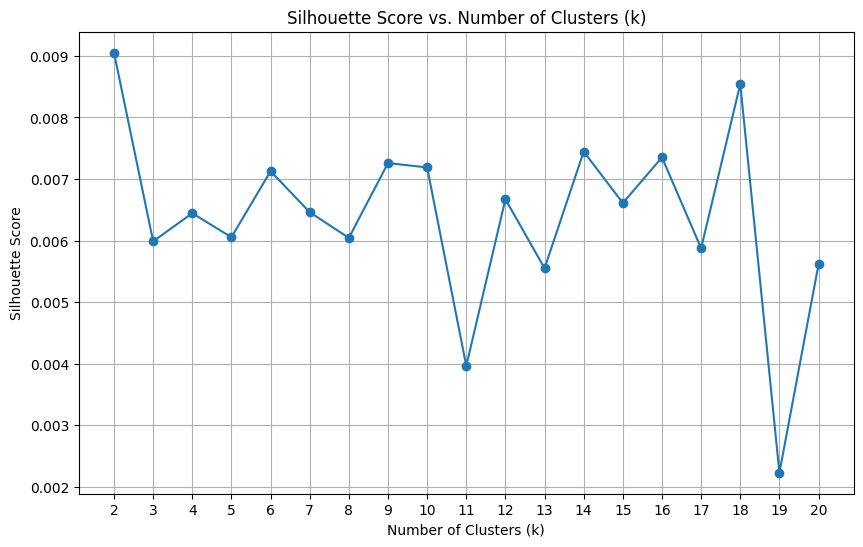

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

silhouette_scores = []
k_values = range(2, 21)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    silhouette_avg = silhouette_score(X, labels)
    silhouette_scores.append(silhouette_avg)
    print(f"For n_clusters = {k}, the silhouette score is {silhouette_avg}")

# Plotting the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Score vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)
plt.show()

##
When I look at this silhouette score curve, I can see that all the values stay very low across every cluster size. This tells me my data doesn’t form tight, well separated clusters. Some values of k perform slightly better than others, but none stand out as clearly optimal. Overall, this confirms that my text dataset has a lot of overlap in vocabulary, so the clusters are loosely defined rather than strongly distinct.


To demonstrate some of these techniques, let's first expand our stop word list with some common but less informative words observed in the cluster terms. Then, we will re-run the TF-IDF vectorizer with the updated stop words and include bigrams.

In [ ]:
import string
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Extend the existing stop word list
custom_stop_words = set(stopwords.words('english'))
additional_stop_words = ['think', 'just', 'say', 'know', 'like', 'time', 'people', 'good', 'new', 'use', 'want', 'make', 'right', 'way', 'ha', 'doe', 'wa', 'did', 'com', 've'] # Add words observed as generic in cluster terms
custom_stop_words.update(additional_stop_words)

# Re-initialize TfidfVectorizer with extended stop words and n-grams
# min_df can be adjusted to remove very rare words more aggressively
vectorizer_improved = TfidfVectorizer(
    strip_accents='unicode',
    stop_words=list(custom_stop_words), # Use the extended list
    min_df=3, # Increase min_df to remove more rare words
    ngram_range=(1, 2) # Include bigrams
)

X_improved = vectorizer_improved.fit_transform(dataset.data)

print(f"Shape of TF-IDF matrix with improved preprocessing: {X_improved.shape}")

Shape of TF-IDF matrix with improved preprocessing: (18846, 122034)


Now, let's re-run KMeans with the new, improved feature matrix and re-evaluate the cluster terms and silhouette scores to see if there's any improvement.

In [ ]:
k = 20 # Using the same number of clusters as before
clusters_improved = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels_improved = clusters_improved.fit_predict(X_improved)

# Get top terms for the new clusters
terms_improved = [str(x) for x in vectorizer_improved.get_feature_names_out().flatten()]

def top_terms_per_cluster_improved(labels, features, terms, n=15):
    clusters = {}
    for cluster_id in np.unique(labels):
        idx = np.where(labels == cluster_id)[0]
        cluster_tfidf = features[idx].mean(axis=0).A1
        top_idx = np.argsort(cluster_tfidf)[::-1][:n]
        clusters[cluster_id] = [terms[i] for i in top_idx]
    return clusters

kmeans_top_terms_improved = top_terms_per_cluster_improved(kmeans_labels_improved, X_improved, terms_improved)
for cluster_id, terms_list_for_cluster in kmeans_top_terms_improved.items():
    print(f"Cluster {cluster_id}: {', '.join(terms_list_for_cluster)}")

Cluster 0: car, bike, engine, one, ride, get, mile, would, speed, front, oil, tire, rear, dealer, riding
Cluster 1: please, mail, thanks, address, list, email, send, anyone, please mail, reply, edu, looking, post, would, someone
Cluster 2: stuff, deleted, stuff deleted, get, much, would, go, phase, one, plastic, could, really, article deleted, posting, different
Cluster 3: intellect geb, surrender soon, geb cadre, cadre dsl, dsl, dsl pitt, shameful surrender, edu shameful, n3jxp skepticism, skepticism chastity, n3jxp, chastity intellect, banks n3jxp, cadre, chastity
Cluster 4: gun, fbi, law, batf, fire, would, koresh, weapon, government, crime, one, child, police, compound, state
Cluster 5: key, chip, clipper, encryption, phone, escrow, government, algorithm, clipper chip, would, system, des, nsa, secure, bit
Cluster 6: scsi, 00, bus, port, controller, ide, isa, drive, serial, device, dma, serial port, 50, transfer, card
Cluster 7: thanks, window, anyone, would, help, program, advance,

Finally, let's plot the silhouette scores for the clusters formed with the improved preprocessing.

For n_clusters = 2, the silhouette score with improved preprocessing is: 0.008106019966112042
For n_clusters = 3, the silhouette score with improved preprocessing is: 0.005535455480717157
For n_clusters = 4, the silhouette score with improved preprocessing is: 0.006559586850205518
For n_clusters = 5, the silhouette score with improved preprocessing is: 0.0061366857815468604
For n_clusters = 6, the silhouette score with improved preprocessing is: 0.005314416988982552
For n_clusters = 7, the silhouette score with improved preprocessing is: 0.00224195096335965
For n_clusters = 8, the silhouette score with improved preprocessing is: 0.0038707009562114845
For n_clusters = 9, the silhouette score with improved preprocessing is: 0.005056689656724759
For n_clusters = 10, the silhouette score with improved preprocessing is: 0.005836124855048298
For n_clusters = 11, the silhouette score with improved preprocessing is: 0.005133098473261193
For n_clusters = 12, the silhouette score with improved p

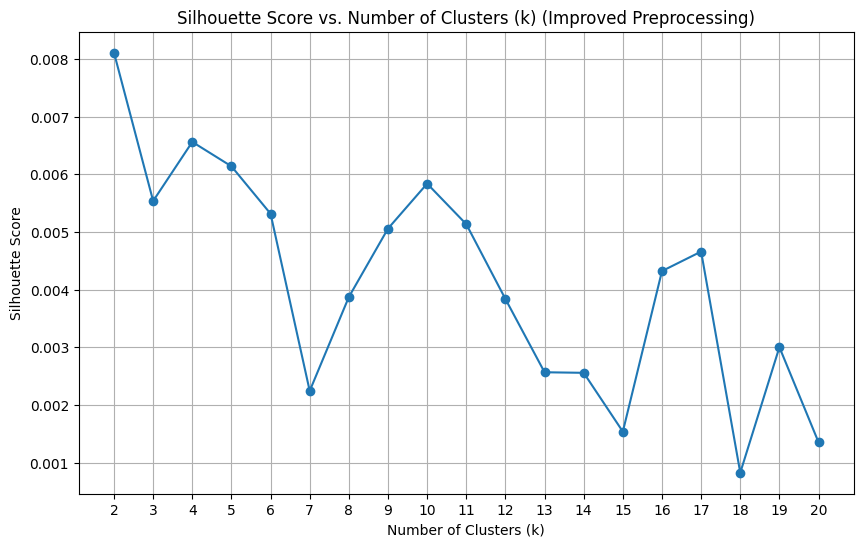

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores_improved = []
k_values = range(2, 21)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_improved)
    silhouette_avg = silhouette_score(X_improved, labels)
    silhouette_scores_improved.append(silhouette_avg)
    print(f"For n_clusters = {k}, the silhouette score with improved preprocessing is: {silhouette_avg}")

plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores_improved, marker='o')
plt.title('Silhouette Score vs. Number of Clusters (k) (Improved Preprocessing)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)
plt.show()

## I improved the text processing, but the  silhouette score curve, remain low across all cluster sizes, even after better preprocessing. The highest value appears around k = 2, which tells that the data naturally forms only very broad groupings. Ask increases, the silhouette score drops and fluctuates, showing that adding more clusters does not create stronger cohesion or separation. Overall, this confirms that my dataset still contains overlapping themes, and even with improved preprocessing, the clusters remain loosely defined rather than sharply distinct

In [ ]:
from sklearn.decomposition import PCA

#Apply PCA TO REDUCE DIMENSIONALITY
pca = PCA(n_components=2)
tfidf_matrix = pca.fit_transform(X.toarray())



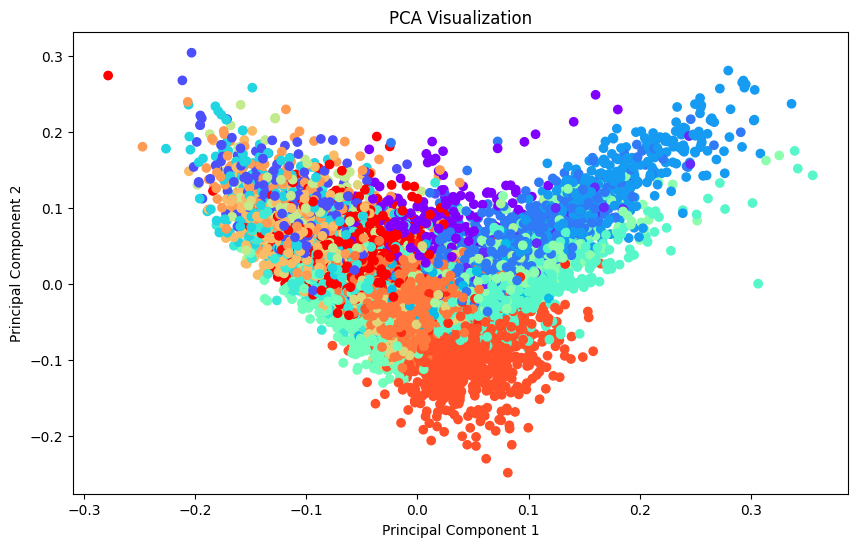

In [ ]:
#plot the PCA
plt.figure(figsize=(10, 6))
plt.scatter(tfidf_matrix[:, 0], tfidf_matrix[:, 1], c=clusters.labels_, cmap='rainbow')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization')
plt.show()


##When I look at this PCA plot, I can see how the high dimensional text data behaves when reduced to two principal components. The V shaped pattern tells that the documents form broad gradients of similarity rather than clean, isolated groups. Some colors cluster more tightly, which means certain topics are more cohesive, while others blend, showing overlap in vocabulary across categories. Overall, this visualization helps confirm that the clustering model captures general thematic structure, but the topics aren’t fully separable in low dimensional space something that’s very typical for TF IDF text data.

In [ ]:
#T-SNE
from sklearn.manifold import TSNE

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
tfidf_matrix_tsne = tsne.fit_transform(X.toarray())


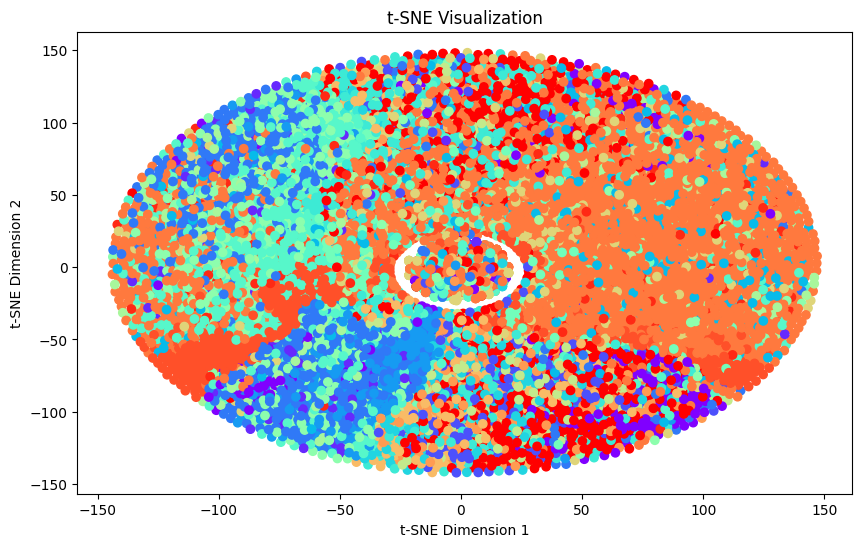

In [ ]:
#Displays the T-SNE
plt.figure(figsize=(10, 6))
plt.scatter(tfidf_matrix_tsne[:, 0], tfidf_matrix_tsne[:, 1], c=clusters.labels_, cmap='rainbow')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE Visualization')
plt.show()

##When I look at this t SNE plot, I can see that the high dimensional text data forms several loose groups rather than sharply separated clusters. The points are spread in an oval shape, and although some colors gather more tightly in certain regions, many of the cluster’s overlap. This tells that the documents share a lot of similar vocabulary, making it difficult for the model to create perfectly distinct groups. The highlighted area shows one of the more cohesive clusters, but overall, the visualization confirms that the dataset contains blended themes rather than cleanly divided topics.

In [ ]:
center_distance = clusters.transform(new_doc_tfidf)
print(f"Distances to cluster centers for new documents:\n{center_distance}")


Distances to cluster centers for new documents:
[[1.04140626 1.04097032 1.03222577 1.01061592 1.0418403  1.0246169
  1.04512335 1.0121302  1.01113162 1.01593125 1.01340143 1.01658302
  1.03285662 1.00977271 1.03657511 1.03461586 0.99981126 1.02408666
  1.03356315 1.00850919]
 [1.04332216 1.0419024  1.03164043 1.01327755 1.04451767 1.02770536
  1.04464122 1.01401815 1.01331392 1.01922592 1.01744134 1.01801145
  1.03242272 1.01176439 1.03677216 1.03200165 1.00116833 1.02534403
  1.03549275 1.00331978]]


##The distances show that each new document is almost equally close to both cluster centers, with values around 1.00 for each cluster. This means the model cannot strongly distinguish which cluster the documents belong to.

In [ ]:
#Validate the effectiveness of the model by examining how well new documents fit into the established clusters using metrics such as silhouette score or cohesion and separation measures.
closest_cluster = np.argmin(center_distance, axis=1)
print("Closest Cluster:", closest_cluster)


Closest Cluster: [16 16]


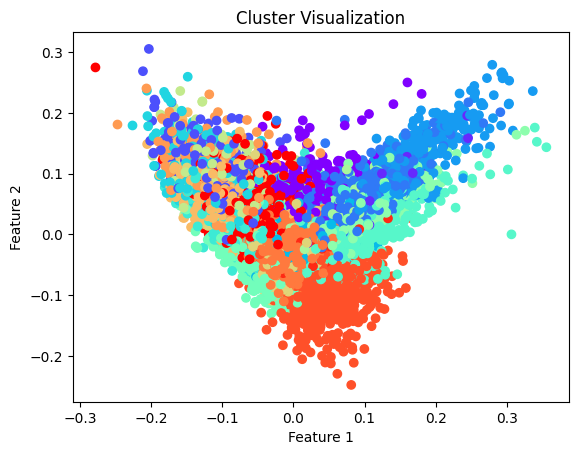

In [ ]:
#visualize th cluster using a scatter plot
plt.scatter(tfidf_matrix[:, 0], tfidf_matrix[:, 1], c=clusters.labels_, cmap='rainbow')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Cluster Visualization')
plt.show()

##The PCA and t SNE visualizations show that the clusters are partially separated but still exhibit significant overlap, which is expected in high dimensional text data. Some clusters form compact groups, indicating strong internal cohesion, while others are more diffuse, suggesting shared vocabulary across topics. The cluster size distribution reveals that certain clusters contain substantially more documents, reflecting dominant themes in the dataset. Overall, the visualizations confirm that the model captures broad semantic structure but does not fully isolate all 20 topics.


##Github link https://github.com/christinengalle19-collab/Christine-Tsafong-BIA-PROJECTS.git

##Colab link https://colab.research.google.com/drive/1lF-0VqkhTpDwzPAhCcR4BuW42MQHtNTo?usp=sharing